In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0
import matplotlib.pyplot as plt

In [15]:
class AddGaussianNoise:
    def __init__(self, std=0.03):
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        return torch.clamp(tensor + noise, 0, 1)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),

    transforms.ToTensor(),

    AddGaussianNoise(std=0.03),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = ImageFolder(
    root="processed/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    root="processed/val",
    transform=test_transform
)

test_dataset = ImageFolder(
    root="processed/test",
    transform=test_transform
)

In [6]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

print(train_dataset.classes)

4716
590
590
['fake', 'real']


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [9]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Replace final layer (1000 classes → 2 classes)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [22]:
EPOCHS = 20

best_val_acc = 0.0

In [23]:
from tqdm import tqdm
import torch

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")

        loop.set_postfix(
            loss=running_loss/(total/labels.size(0)),
            acc=100*correct/total
        )

    train_acc = 100 * correct / total

    #Validation

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total

    print(f"\nTrain Accuracy : {train_acc:.2f}%")
    print(f"Validation Accuracy : {val_acc:.2f}%")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "best_model.pth")

        print("Best model saved!")

Epoch 1/20: 100%|██████████| 148/148 [12:06<00:00,  4.91s/it, acc=96.3, loss=0.0382] 



Train Accuracy : 96.31%
Validation Accuracy : 88.64%
Best model saved!


Epoch 2/20: 100%|██████████| 148/148 [12:23<00:00,  5.02s/it, acc=97.6, loss=0.0257]



Train Accuracy : 97.65%
Validation Accuracy : 92.03%
Best model saved!


Epoch 3/20: 100%|██████████| 148/148 [11:10<00:00,  4.53s/it, acc=98, loss=0.02]     


...


Train Accuracy : 98.98%
Validation Accuracy : 87.80%


Epoch 8/20: 100%|██████████| 148/148 [11:02<00:00,  4.47s/it, acc=99.1, loss=0.00896]



Train Accuracy : 99.11%
Validation Accuracy : 91.36%


Epoch 9/20:  43%|████▎     | 64/148 [05:42<07:29,  5.35s/it, acc=98.8, loss=0.027] 


KeyboardInterrupt: 

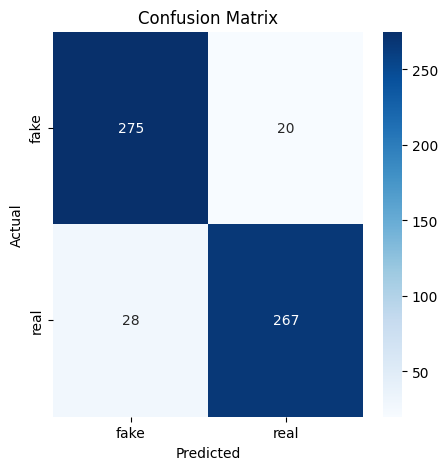

              precision    recall  f1-score   support

        fake       0.91      0.93      0.92       295
        real       0.93      0.91      0.92       295

    accuracy                           0.92       590
   macro avg       0.92      0.92      0.92       590
weighted avg       0.92      0.92      0.92       590



In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))